In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

#chargement du dataset , en specifinat la date comme index
bitcoin = pd.read_csv("BTC-EUR.csv" , index_col= 'Date' , parse_dates= True)

In [19]:
bitcoin


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-10-04,3.700000,3.821000,3.746000,3.750000,3.750000,1357
2011-10-05,3.750000,3.820000,3.650000,3.676000,3.676000,3349
2011-10-06,3.676000,3.743000,3.450000,3.550000,3.550000,6642
2011-10-07,3.550000,3.590000,2.900000,3.293000,3.293000,7135
2011-10-08,3.293000,3.283000,2.872000,2.890000,2.890000,2007
...,...,...,...,...,...,...
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316
2019-10-02,7625.560059,7663.270020,7489.770020,7655.250000,7655.250000,51871334


In [20]:
bitcoin.index

DatetimeIndex(['2011-10-04', '2011-10-05', '2011-10-06', '2011-10-07',
               '2011-10-08', '2011-10-09', '2011-10-10', '2011-10-11',
               '2011-10-12', '2011-10-13',
               ...
               '2019-09-25', '2019-09-26', '2019-09-27', '2019-09-28',
               '2019-09-29', '2019-09-30', '2019-10-01', '2019-10-02',
               '2019-10-03', '2019-10-04'],
              dtype='datetime64[ns]', name='Date', length=2923, freq=None)

In [21]:
#filtrage des donnés pour concervé la plage de l'année 2019
bit_2019=bitcoin.loc['2019']
bit_2019

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2019-01-01,3247.790039,3380.320068,3214.340088,3372.090088,3372.090088,28207690
2019-01-02,3372.090088,3482.489990,3328.800049,3468.399902,3468.399902,39302386
2019-01-03,3468.399902,3472.800049,3319.760010,3345.330078,3345.330078,38242406
2019-01-04,3345.330078,3400.840088,3316.639893,3370.939941,3370.939941,33665676
2019-01-05,3370.939941,3423.320068,3352.530029,3359.159912,3359.159912,21586634
...,...,...,...,...,...,...
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316
2019-10-02,7625.560059,7663.270020,7489.770020,7655.250000,7655.250000,51871334


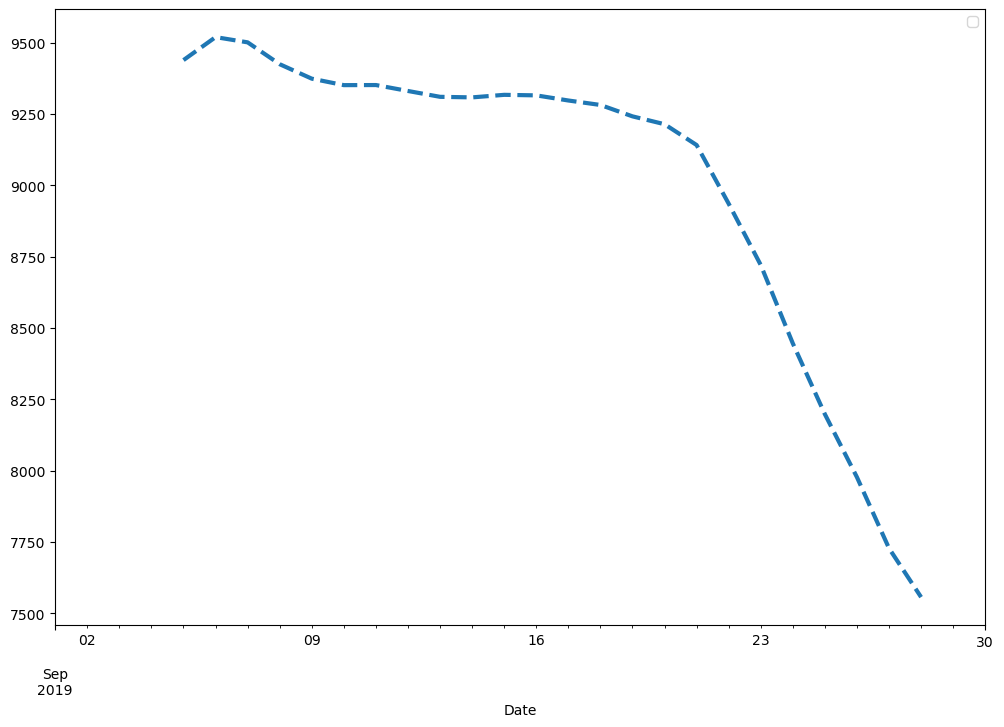

In [30]:
#utilisation du rolling pour calculer la moyenne mobile au mois de septembre 2019
plt.figure(figsize=(12,8))
bitcoin.loc["2019-09", "Close"].rolling(window=7,center=True).mean().shift(1).plot( label='moving avarage',lw=3, ls= "--")
plt.legend("")

<Axes: xlabel='Date'>

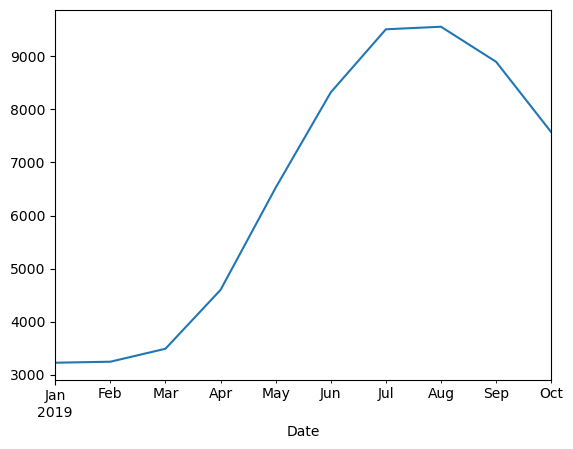

In [27]:
#afficher la moyenne mensuelle des prix de cloture de l'année 2019
bitcoin.loc["2019","Close"].resample("ME").mean().plot()

<Axes: xlabel='Date'>

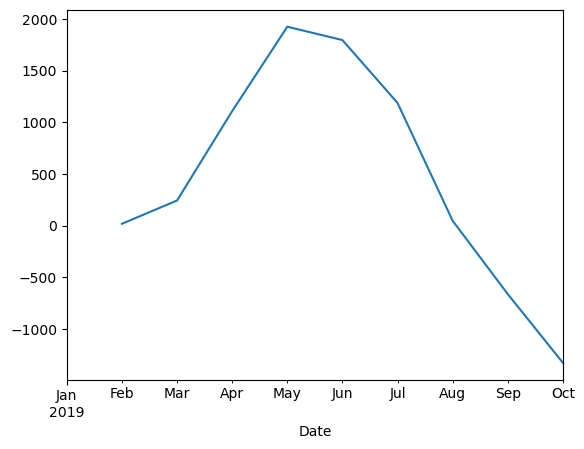

In [28]:
bitcoin.loc["2019","Close"].resample("ME").mean().diff().plot()

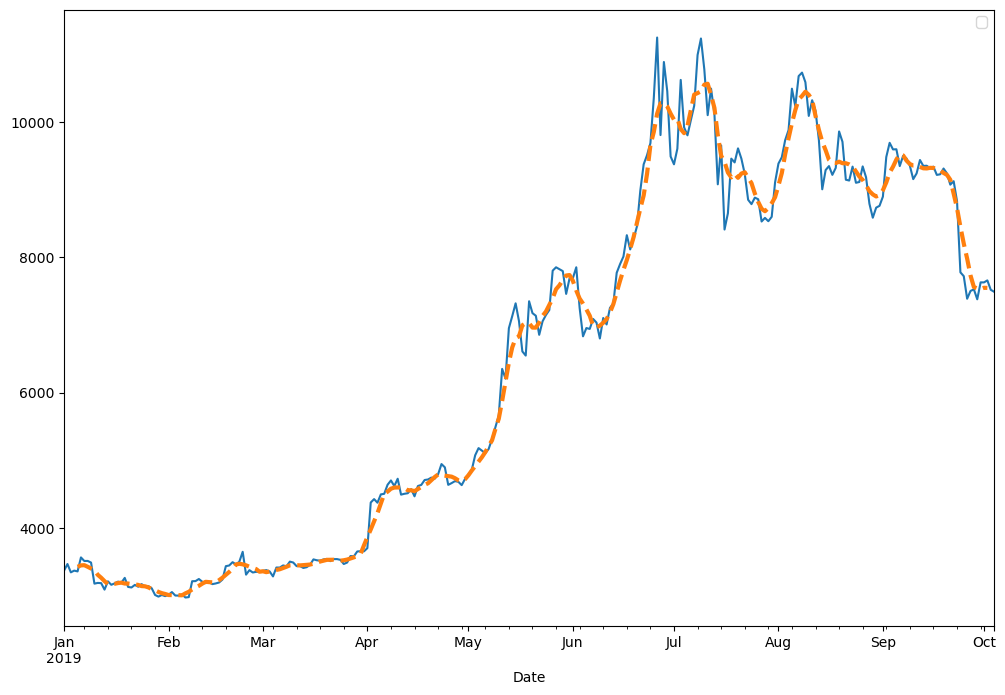

In [33]:
#tracer sur un meme graphique le prix réel close et le prix de la moyenne décaléée d'un mois
plt.figure(figsize=(12,8))
bitcoin.loc["2019", "Close"].plot()
bitcoin.loc["2019", "Close"].rolling(window=7,center=True).mean().shift(1).plot( label='moving avarage',lw=3, ls= "--")
plt.legend("")